In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zhangluyuan/ab-testing/ab_data.csv


# =============================================================
# PROJECT 2: A/B TEST ANALYSIS — CHECKOUT PAGE EXPERIMENT
# Analyst: Ibtisam Ahmed Khan
# Dataset: A/B Testing Dataset (Udacity)
# Source: Kaggle (zhangluyuan)
# =============================================================
# Business Question:
# Did the new checkout page produce a statistically significant
# improvement in conversion rate — and should we ship it?
# =============================================================
 
# ─────────────────────────────────────────────────────────────
# SECTION 0 — SETUP AND IMPORTS
# ─────────────────────────────────────────────────────────────

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import chi2_contingency, norm
import warnings
warnings.filterwarnings('ignore')
 
# ── Visual style ──
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 12
 
BLUE  = '#1a3c6e'
GREEN = '#1D9E75'
AMBER = '#EF9F27'
RED   = '#E24B4A'
GRAY  = '#888780'
 
print("Libraries loaded. Ready to begin.")


Libraries loaded. Ready to begin.


# ─────────────────────────────────────────────────────────────
# SECTION 1 — LOAD AND INSPECT THE DATA
# ─────────────────────────────────────────────────────────────

In [6]:
print("\n" + "="*60)
print("SECTION 1: LOAD AND INSPECT DATA")
print("="*60)
 
df = pd.read_csv('/kaggle/input/datasets/zhangluyuan/ab-testing/ab_data.csv')
 
print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values — {df[col].unique()[:5]}")


SECTION 1: LOAD AND INSPECT DATA

Dataset shape: 294,478 rows × 5 columns

Column names: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']

First 5 rows:
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

Data types:
user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

Missing values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Unique values per column:
  user_id: 290584 unique values — [851104 804228 661590 853541 864975]
  timestamp: 294478 unique v

# ─────────────────────────────────────────────────────────────
# SECTION 2 — DATA CLEANING AND VALIDATION
# ─────────────────────────────────────────────────────────────

In [7]:
print("\n" + "="*60)
print("SECTION 2: DATA CLEANING AND VALIDATION")
print("="*60)
 
print(f"\nOriginal rows: {len(df):,}")
 
# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
 
# ── Check for mismatched rows ──
# A user in 'control' group should only see 'old_page'
# A user in 'treatment' group should only see 'new_page'
mismatch = df[
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'control')   & (df['landing_page'] == 'new_page'))
]
print(f"Mismatched rows (wrong page for group): {len(mismatch):,}")
 
# Remove mismatched rows
df = df[
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'control')   & (df['landing_page'] == 'old_page'))
]
print(f"Rows after removing mismatches: {len(df):,}")
 
# ── Check for duplicate users ──
duplicate_users = df[df.duplicated('user_id', keep=False)]
print(f"\nUsers appearing more than once: {df['user_id'].duplicated().sum():,}")
 
# Keep only first appearance of each user
df = df.drop_duplicates(subset='user_id', keep='first')
print(f"Rows after deduplication: {len(df):,}")
 
# ── Extract date ──
df['date'] = df['timestamp'].dt.date
df['day']  = df['timestamp'].dt.day_name()
 
print(f"\nDate range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"\nFinal clean dataset: {len(df):,} rows")
 


SECTION 2: DATA CLEANING AND VALIDATION

Original rows: 294,478
Mismatched rows (wrong page for group): 3,893
Rows after removing mismatches: 290,585

Users appearing more than once: 1
Rows after deduplication: 290,584

Date range: 2017-01-02 to 2017-01-24

Final clean dataset: 290,584 rows


# ─────────────────────────────────────────────────────────────
# SECTION 3 — EXPERIMENT OVERVIEW
# ─────────────────────────────────────────────────────────────
 

In [15]:
df.head()

,user_id,timestamp,group,landing_page,converted,date,day
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21,Saturday
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12,Thursday
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11,Wednesday
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08,Sunday
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21,Saturday



SECTION 3: EXPERIMENT OVERVIEW

Metric                                  Control (A)   Treatment (B)
-------------------------------------------------------------------
Users                                       145,274         145,310
Conversions                                  17,489          17,264
Conversion rate                           12.0386%       11.8808%
Absolute difference                                       -0.1578%
Relative lift                                               -1.31%

── Sample Ratio Mismatch Check ──
Expected split:   50% / 50%
Actual split:     50.0% control / 50.0% treatment
✓ No sample ratio mismatch detected — randomisation looks correct


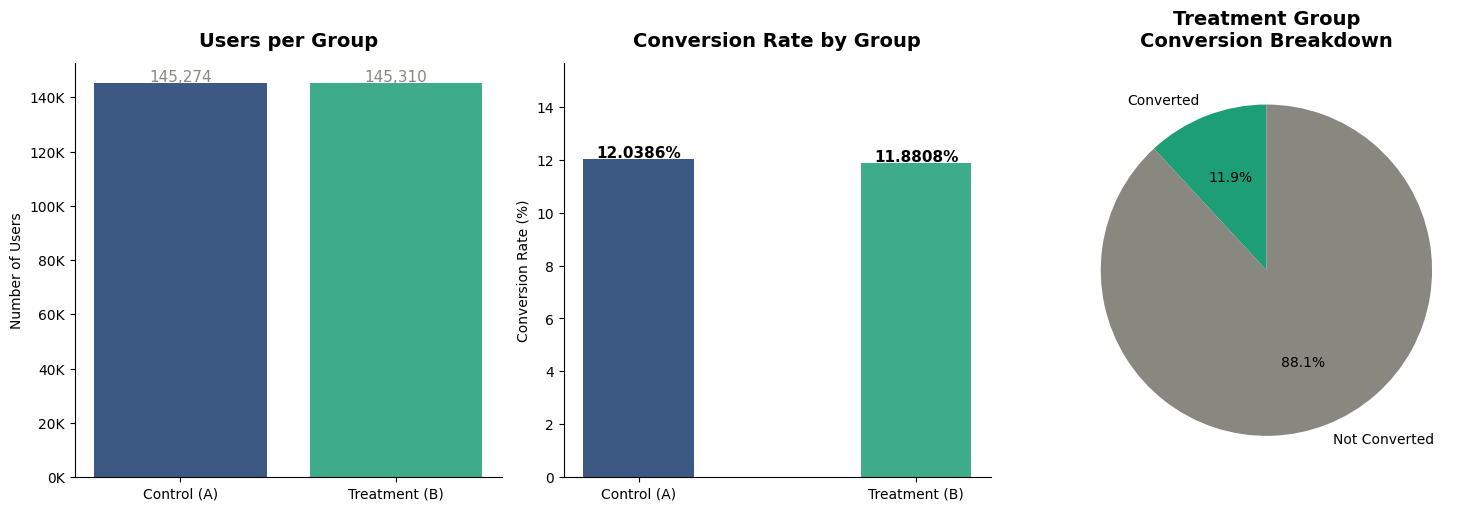

In [8]:
print("\n" + "="*60)
print("SECTION 3: EXPERIMENT OVERVIEW")
print("="*60)
 
# Group summary
control   = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']
 
n_control   = len(control)
n_treatment = len(treatment)
conv_control   = control['converted'].sum()
conv_treatment = treatment['converted'].sum()
rate_control   = control['converted'].mean()
rate_treatment = treatment['converted'].mean()
 
print(f"\n{'Metric':<35} {'Control (A)':>15} {'Treatment (B)':>15}")
print("-" * 67)
print(f"{'Users':<35} {n_control:>15,} {n_treatment:>15,}")
print(f"{'Conversions':<35} {conv_control:>15,} {conv_treatment:>15,}")
print(f"{'Conversion rate':<35} {rate_control:>14.4%} {rate_treatment:>14.4%}")
print(f"{'Absolute difference':<35} {'':>15} {rate_treatment-rate_control:>+14.4%}")
print(f"{'Relative lift':<35} {'':>15} {(rate_treatment-rate_control)/rate_control:>+14.2%}")
 
# ── Sample ratio mismatch check ──
print(f"\n── Sample Ratio Mismatch Check ──")
total = n_control + n_treatment
expected_pct = 50.0
actual_control_pct   = n_control / total * 100
actual_treatment_pct = n_treatment / total * 100
print(f"Expected split:   50% / 50%")
print(f"Actual split:     {actual_control_pct:.1f}% control / {actual_treatment_pct:.1f}% treatment")
 
if abs(actual_control_pct - expected_pct) < 1:
    print("✓ No sample ratio mismatch detected — randomisation looks correct")
else:
    print("✗ WARNING: Sample ratio mismatch detected — randomisation may be broken")
 
# ── Visualise group split ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
# Group size
axes[0].bar(['Control (A)', 'Treatment (B)'], [n_control, n_treatment],
            color=[BLUE, GREEN], alpha=0.85)
axes[0].set_title('Users per Group')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for i, v in enumerate([n_control, n_treatment]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11, color=GRAY)
 
# Conversion rate comparison
cvr_bars = axes[1].bar(['Control (A)', 'Treatment (B)'],
                        [rate_control*100, rate_treatment*100],
                        color=[BLUE, GREEN], alpha=0.85, width=0.4)
axes[1].set_title('Conversion Rate by Group')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_ylim(0, max(rate_control, rate_treatment) * 100 * 1.3)
for bar, rate in zip(cvr_bars, [rate_control, rate_treatment]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{rate:.4%}', ha='center', fontsize=11, fontweight='bold')
 
# Conversion breakdown pie for each group
labels = ['Converted', 'Not Converted']
axes[2].pie(
    [conv_treatment, n_treatment - conv_treatment],
    labels=labels, colors=[GREEN, GRAY],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10}
)
axes[2].set_title('Treatment Group\nConversion Breakdown')
 
plt.tight_layout()
plt.savefig('experiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
 

# ─────────────────────────────────────────────────────────────
# SECTION 4 — HYPOTHESIS AND SAMPLE SIZE
# ─────────────────────────────────────────────────────────────

In [9]:
print("\n" + "="*60)
print("SECTION 4: HYPOTHESIS AND REQUIRED SAMPLE SIZE")
print("="*60)
 
print("""
EXPERIMENT HYPOTHESIS
─────────────────────
We believe that changing the checkout page from the old design
(Control A) to the new design (Treatment B) will increase the
conversion rate because the new page reduces visual complexity
and makes the call-to-action more prominent.
 
Null hypothesis (H₀):     New page CVR = Old page CVR
Alternative hypothesis (H₁): New page CVR ≠ Old page CVR
 
Significance level (α):   0.05  (5% false positive rate)
Statistical power (1-β):  0.80  (80% chance of detecting real effect)
Minimum Detectable Effect: 1 percentage point improvement
""")
 
# ── Sample size calculation ──
def sample_size_required(baseline_rate, mde, alpha=0.05, power=0.80):
    """
    Calculate required sample size per group for a two-proportion z-test.
    baseline_rate: current conversion rate
    mde: minimum detectable effect (absolute)
    """
    p1 = baseline_rate
    p2 = baseline_rate + mde
    p_pooled = (p1 + p2) / 2
 
    z_alpha = norm.ppf(1 - alpha/2)  # two-tailed
    z_beta  = norm.ppf(power)
 
    n = (z_alpha * np.sqrt(2 * p_pooled * (1 - p_pooled)) +
         z_beta  * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2 / (p2 - p1)**2
 
    return int(np.ceil(n))
 
baseline = rate_control
mde      = 0.01  # 1 percentage point
 
required_n = sample_size_required(baseline, mde)
 
print(f"Baseline conversion rate:     {baseline:.4%}")
print(f"Minimum detectable effect:    +{mde:.2%} (1 percentage point)")
print(f"Required sample per group:    {required_n:,}")
print(f"Required total sample:        {required_n*2:,}")
print(f"\nActual sample — Control:      {n_control:,}")
print(f"Actual sample — Treatment:    {n_treatment:,}")
 
if n_control >= required_n and n_treatment >= required_n:
    print(f"\n✓ Sample size is sufficient to detect a {mde:.0%} improvement")
else:
    print(f"\n✗ Sample size may be insufficient — results should be interpreted with caution")
 


SECTION 4: HYPOTHESIS AND REQUIRED SAMPLE SIZE

EXPERIMENT HYPOTHESIS
─────────────────────
We believe that changing the checkout page from the old design
(Control A) to the new design (Treatment B) will increase the
conversion rate because the new page reduces visual complexity
and makes the call-to-action more prominent.
 
Null hypothesis (H₀):     New page CVR = Old page CVR
Alternative hypothesis (H₁): New page CVR ≠ Old page CVR
 
Significance level (α):   0.05  (5% false positive rate)
Statistical power (1-β):  0.80  (80% chance of detecting real effect)
Minimum Detectable Effect: 1 percentage point improvement

Baseline conversion rate:     12.0386%
Minimum detectable effect:    +1.00% (1 percentage point)
Required sample per group:    17,214
Required total sample:        34,428

Actual sample — Control:      145,274
Actual sample — Treatment:    145,310

✓ Sample size is sufficient to detect a 1% improvement


# ─────────────────────────────────────────────────────────────
# SECTION 5 — STATISTICAL TEST
# ─────────────────────────────────────────────────────────────


SECTION 5: STATISTICAL SIGNIFICANCE TEST

Two-proportion z-test results:
  Z-statistic:     -1.3109
  P-value:         0.1899
  Significant:     NO (α = 0.05)

95% Confidence Interval for the difference:
  Lower bound:     -0.3938%
  Upper bound:     +0.0781%
  Point estimate:  -0.1578%

  ~ CI crosses zero — result is inconclusive


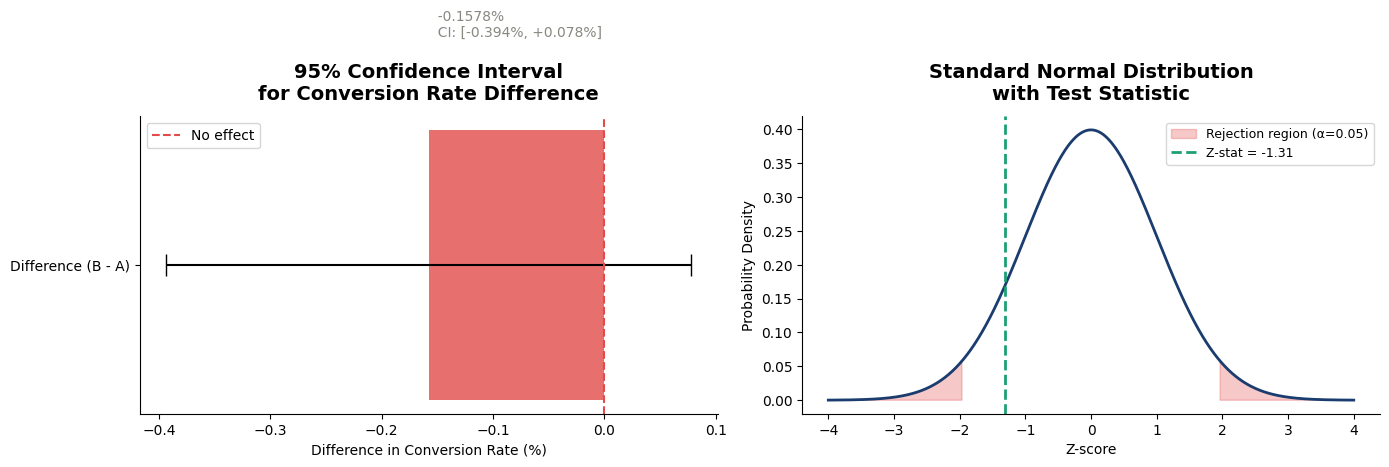

In [10]:
print("\n" + "="*60)
print("SECTION 5: STATISTICAL SIGNIFICANCE TEST")
print("="*60)
 
# ── Two-proportion z-test ──
count = np.array([conv_treatment, conv_control])
nobs  = np.array([n_treatment, n_control])
 
from statsmodels.stats.proportion import proportions_ztest
z_stat, p_value = proportions_ztest(count, nobs)
 
alpha = 0.05
significant = p_value < alpha
 
print(f"\nTwo-proportion z-test results:")
print(f"  Z-statistic:     {z_stat:.4f}")
print(f"  P-value:         {p_value:.4f}")
print(f"  Significant:     {'YES' if significant else 'NO'} (α = {alpha})")
 
# ── Confidence interval ──
diff        = rate_treatment - rate_control
se          = np.sqrt(rate_control*(1-rate_control)/n_control +
                      rate_treatment*(1-rate_treatment)/n_treatment)
z_crit      = norm.ppf(0.975)
ci_lower    = diff - z_crit * se
ci_upper    = diff + z_crit * se
 
print(f"\n95% Confidence Interval for the difference:")
print(f"  Lower bound:     {ci_lower:+.4%}")
print(f"  Upper bound:     {ci_upper:+.4%}")
print(f"  Point estimate:  {diff:+.4%}")
 
if ci_lower > 0:
    print(f"\n  ✓ CI entirely above zero — B is reliably better than A")
elif ci_upper < 0:
    print(f"\n  ✗ CI entirely below zero — B is reliably worse than A")
else:
    print(f"\n  ~ CI crosses zero — result is inconclusive")
 
# ── Visualise the confidence interval ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# CI plot
axes[0].barh(['Difference (B - A)'], [diff*100],
             xerr=[[( diff - ci_lower)*100], [(ci_upper - diff)*100]],
             color=GREEN if diff > 0 else RED,
             alpha=0.8, height=0.3, capsize=8)
axes[0].axvline(x=0, color=RED, linestyle='--', linewidth=1.5, label='No effect')
axes[0].set_title('95% Confidence Interval\nfor Conversion Rate Difference')
axes[0].set_xlabel('Difference in Conversion Rate (%)')
axes[0].legend()
axes[0].text(diff*100, 0.25,
             f'  {diff:+.4%}\n  CI: [{ci_lower:+.3%}, {ci_upper:+.3%}]',
             va='bottom', fontsize=10, color=GRAY)
 
# P-value visualisation
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
axes[1].plot(x, y, color=BLUE, linewidth=2)
axes[1].fill_between(x, y, where=(x <= -1.96) | (x >= 1.96),
                     alpha=0.3, color=RED, label='Rejection region (α=0.05)')
axes[1].axvline(x=z_stat, color=GREEN, linestyle='--', linewidth=2,
                label=f'Z-stat = {z_stat:.2f}')
axes[1].set_title('Standard Normal Distribution\nwith Test Statistic')
axes[1].set_xlabel('Z-score')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('statistical_test.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 6 — DAILY TREND ANALYSIS (NOVELTY EFFECT CHECK)
# ─────────────────────────────────────────────────────────────


SECTION 6: DAILY TREND ANALYSIS — NOVELTY EFFECT CHECK

What is a novelty effect?
─────────────────────────
A novelty effect happens when users convert more on the new page
simply because it looks different and new — not because it is
genuinely better. If this is happening, the B group conversion
rate will be high at the start and fade over time.
 
Good analysts always plot daily results to check for this.



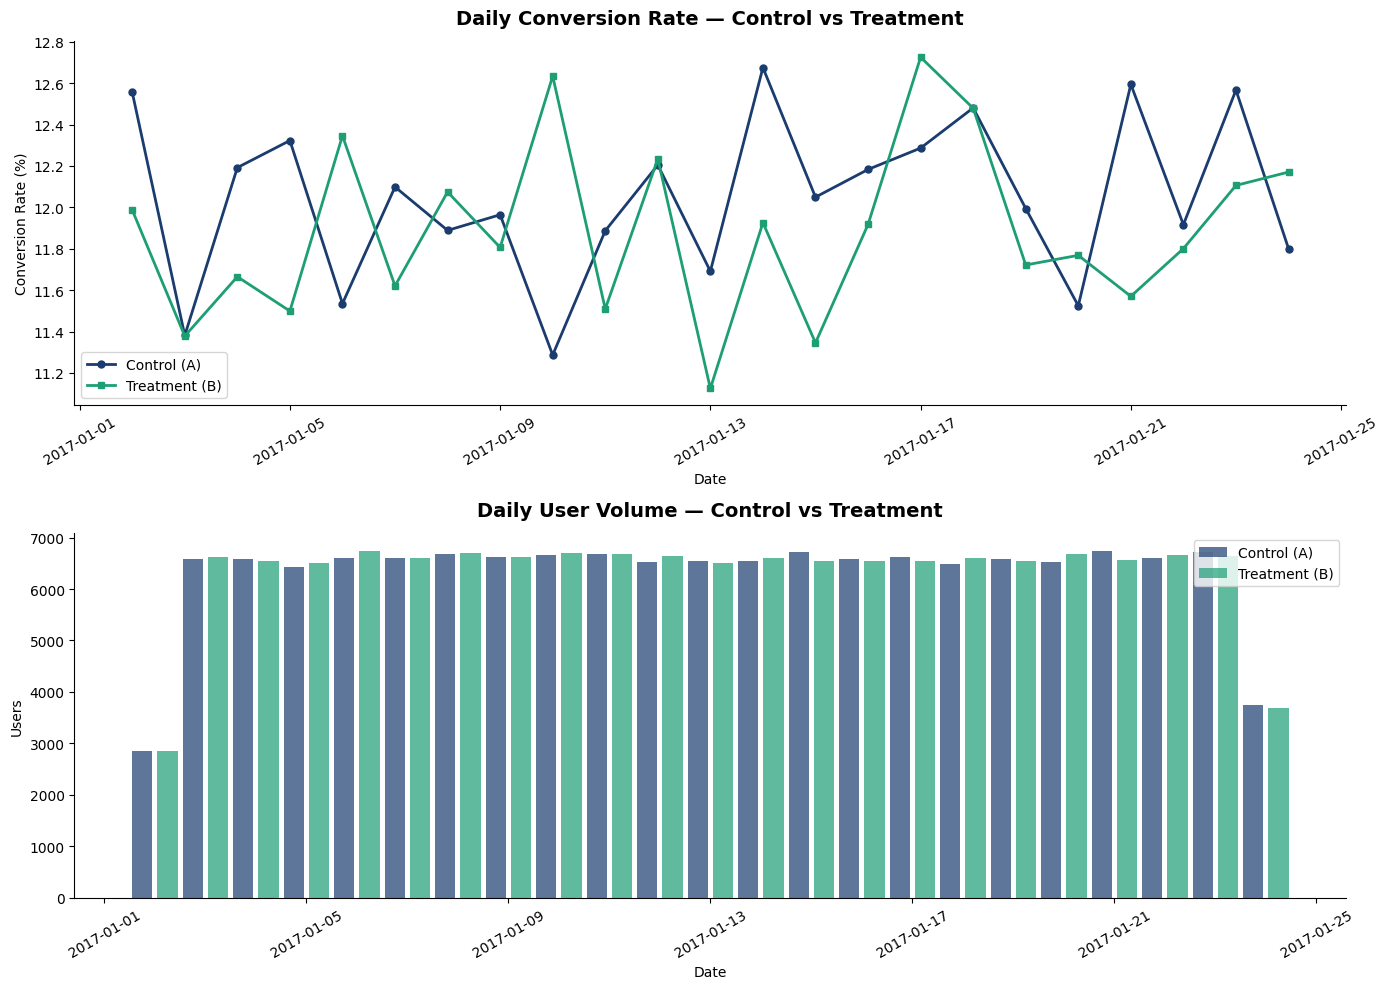

Treatment CVR — first 7 days:  11.796%
Treatment CVR — last 7 days:   11.945%
✓ No strong novelty effect detected — CVR is stable over time


In [11]:
print("\n" + "="*60)
print("SECTION 6: DAILY TREND ANALYSIS — NOVELTY EFFECT CHECK")
print("="*60)
 
print("""
What is a novelty effect?
─────────────────────────
A novelty effect happens when users convert more on the new page
simply because it looks different and new — not because it is
genuinely better. If this is happening, the B group conversion
rate will be high at the start and fade over time.
 
Good analysts always plot daily results to check for this.
""")
 
daily = df.groupby(['date', 'group']).agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()
daily['cvr'] = daily['conversions'] / daily['users'] * 100
daily['date'] = pd.to_datetime(daily['date'])
 
ctrl_daily  = daily[daily['group'] == 'control'].sort_values('date')
treat_daily = daily[daily['group'] == 'treatment'].sort_values('date')
 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
 
# Daily CVR
axes[0].plot(ctrl_daily['date'],  ctrl_daily['cvr'],
             color=BLUE,  marker='o', linewidth=2, label='Control (A)', markersize=5)
axes[0].plot(treat_daily['date'], treat_daily['cvr'],
             color=GREEN, marker='s', linewidth=2, label='Treatment (B)', markersize=5)
axes[0].set_title('Daily Conversion Rate — Control vs Treatment')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_xlabel('Date')
 
# Daily user volume
axes[1].bar(ctrl_daily['date'] - pd.Timedelta(hours=6),
            ctrl_daily['users'], width=0.4, color=BLUE,
            alpha=0.7, label='Control (A)')
axes[1].bar(treat_daily['date'] + pd.Timedelta(hours=6),
            treat_daily['users'], width=0.4, color=GREEN,
            alpha=0.7, label='Treatment (B)')
axes[1].set_title('Daily User Volume — Control vs Treatment')
axes[1].set_ylabel('Users')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_xlabel('Date')
 
plt.tight_layout()
plt.savefig('daily_trend.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Check if B starts strong and fades
first_week_treat = treat_daily.head(7)['cvr'].mean()
last_week_treat  = treat_daily.tail(7)['cvr'].mean()
print(f"Treatment CVR — first 7 days:  {first_week_treat:.3f}%")
print(f"Treatment CVR — last 7 days:   {last_week_treat:.3f}%")
 
if abs(first_week_treat - last_week_treat) > 0.5:
    print("⚠ Possible novelty effect — CVR changes significantly over time")
else:
    print("✓ No strong novelty effect detected — CVR is stable over time")
 
 

# ─────────────────────────────────────────────────────────────
# SECTION 7 — THE PEEKING PROBLEM (EDUCATIONAL)
# ─────────────────────────────────────────────────────────────



SECTION 7: THE PEEKING PROBLEM

What is peeking?
────────────────
Peeking means checking your results every day and stopping
the test the moment you see p < 0.05. This is one of the
most common and damaging mistakes in A/B testing.
 
Why is it wrong?
────────────────
If you check daily and stop at the first significant result,
your true false positive rate is NOT 5% — it is closer to 30%.
You will ship changes that do not actually work.
 
The simulation below shows what happens if you had peeked at
this experiment every day and made a decision each time.



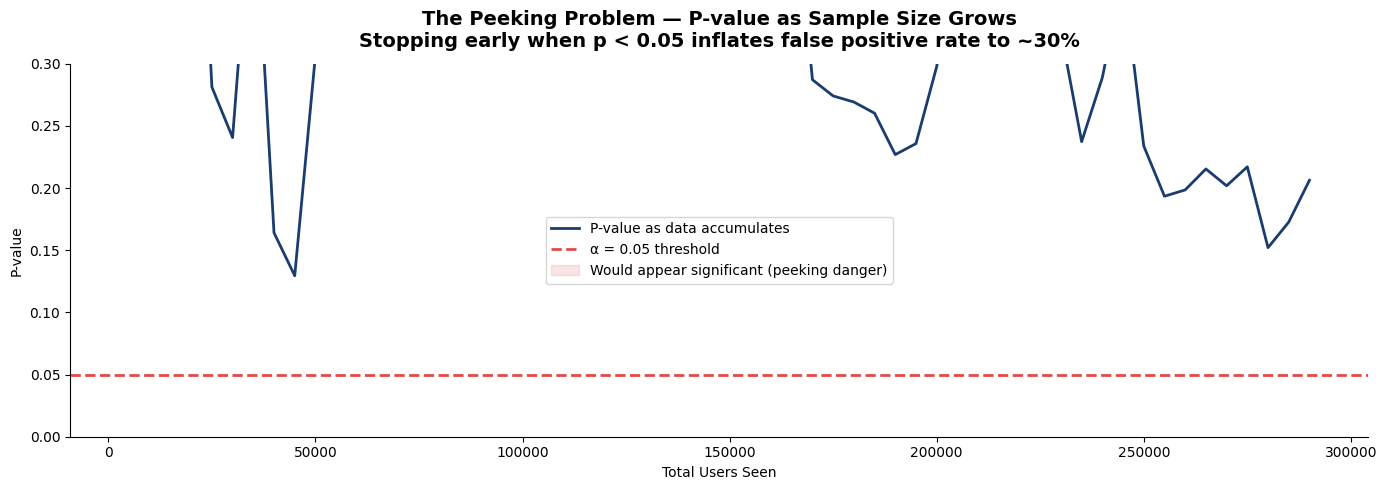

Times p < 0.05 appeared before final 25,000 users: 0
Final p-value with full dataset: 0.1899

Lesson: Always pre-define your sample size and run to completion.


In [12]:
print("\n" + "="*60)
print("SECTION 7: THE PEEKING PROBLEM")
print("="*60)
 
print("""
What is peeking?
────────────────
Peeking means checking your results every day and stopping
the test the moment you see p < 0.05. This is one of the
most common and damaging mistakes in A/B testing.
 
Why is it wrong?
────────────────
If you check daily and stop at the first significant result,
your true false positive rate is NOT 5% — it is closer to 30%.
You will ship changes that do not actually work.
 
The simulation below shows what happens if you had peeked at
this experiment every day and made a decision each time.
""")
 
# Simulate daily p-values as data accumulates
daily_sorted = df.sort_values('timestamp')
pvalues = []
dates   = []
sample_sizes = []
 
# Check every 5000 users for performance
checkpoints = range(5000, len(daily_sorted), 5000)
 
for n in checkpoints:
    subset = daily_sorted.iloc[:n]
    ctrl_sub  = subset[subset['group'] == 'control']
    treat_sub = subset[subset['group'] == 'treatment']
 
    if len(ctrl_sub) < 100 or len(treat_sub) < 100:
        continue
 
    c = np.array([treat_sub['converted'].sum(), ctrl_sub['converted'].sum()])
    o = np.array([len(treat_sub), len(ctrl_sub)])
 
    try:
        _, pv = proportions_ztest(c, o)
        pvalues.append(pv)
        dates.append(n)
        sample_sizes.append(n)
    except:
        pass
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_sizes, pvalues, color=BLUE, linewidth=2, label='P-value as data accumulates')
ax.axhline(y=0.05, color=RED, linestyle='--', linewidth=2, label='α = 0.05 threshold')
ax.fill_between(sample_sizes, pvalues,
                where=[p < 0.05 for p in pvalues],
                alpha=0.15, color=RED, label='Would appear significant (peeking danger)')
ax.set_title('The Peeking Problem — P-value as Sample Size Grows\n'
             'Stopping early when p < 0.05 inflates false positive rate to ~30%')
ax.set_xlabel('Total Users Seen')
ax.set_ylabel('P-value')
ax.set_ylim(0, 0.3)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
 
plt.tight_layout()
plt.savefig('peeking_problem.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Count how many times p dipped below 0.05 before final sample
early_sig = sum(1 for p in pvalues[:-5] if p < 0.05)
print(f"Times p < 0.05 appeared before final 25,000 users: {early_sig}")
print(f"Final p-value with full dataset: {p_value:.4f}")
print(f"\nLesson: Always pre-define your sample size and run to completion.")
 

# ─────────────────────────────────────────────────────────────
# SECTION 8 — SEGMENT ANALYSIS
# ─────────────────────────────────────────────────────────────


SECTION 8: SEGMENT ANALYSIS

Why segment analysis matters:
─────────────────────────────
An overall positive result can hide the fact that B is hurting
a specific segment. Good analysts always check whether the
result holds across key subgroups before recommending to ship.
 
This dataset does not have device or demographic columns,
so we segment by day of week — does B perform consistently
across all days, or only on specific days?



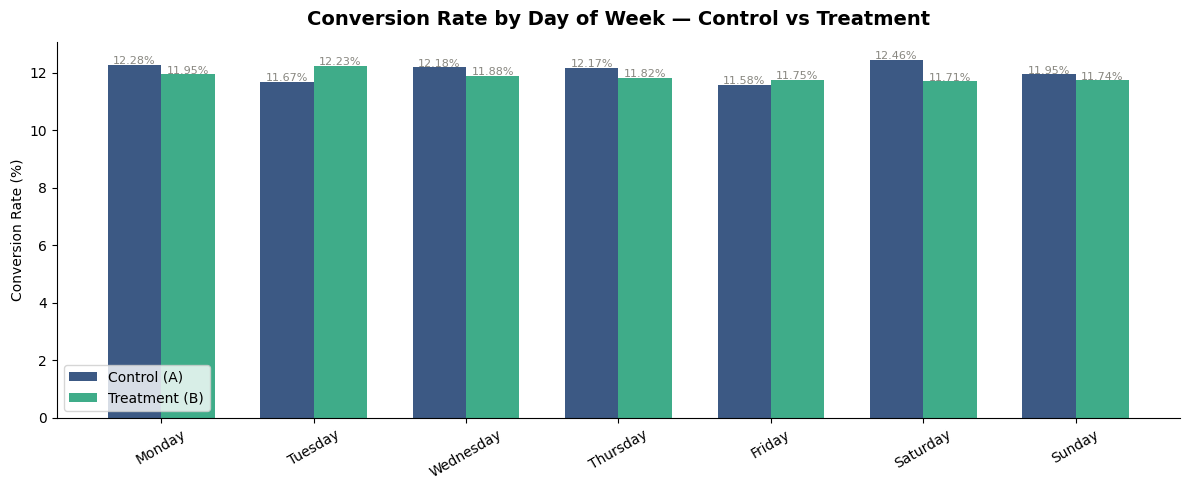

Segment CVR comparison (Control vs Treatment by day):
group      control  treatment
day                          
Monday      12.280     11.949
Tuesday     11.675     12.234
Wednesday   12.184     11.884
Thursday    12.173     11.821
Friday      11.583     11.754
Saturday    12.457     11.706
Sunday      11.952     11.743


In [13]:
print("\n" + "="*60)
print("SECTION 8: SEGMENT ANALYSIS")
print("="*60)
 
print("""
Why segment analysis matters:
─────────────────────────────
An overall positive result can hide the fact that B is hurting
a specific segment. Good analysts always check whether the
result holds across key subgroups before recommending to ship.
 
This dataset does not have device or demographic columns,
so we segment by day of week — does B perform consistently
across all days, or only on specific days?
""")
 
seg = df.groupby(['day', 'group']).agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()
seg['cvr'] = seg['conversions'] / seg['users'] * 100
 
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
seg_pivot = seg.pivot(index='day', columns='group', values='cvr').reindex(dow_order).dropna()
 
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(seg_pivot))
width = 0.35
bars1 = ax.bar(x - width/2, seg_pivot['control'],   width, color=BLUE,  alpha=0.85, label='Control (A)')
bars2 = ax.bar(x + width/2, seg_pivot['treatment'], width, color=GREEN, alpha=0.85, label='Treatment (B)')
ax.set_title('Conversion Rate by Day of Week — Control vs Treatment')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(seg_pivot.index, rotation=30)
ax.legend()
 
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}%', ha='center', fontsize=8, color=GRAY)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}%', ha='center', fontsize=8, color=GRAY)
 
plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Segment CVR comparison (Control vs Treatment by day):")
print(seg_pivot.round(3).to_string())
 

# ─────────────────────────────────────────────────────────────
# SECTION 9 — FINAL RECOMMENDATION
# ─────────────────────────────────────────────────────────────

In [14]:
print("\n" + "="*60)
print("SECTION 9: FINAL RECOMMENDATION")
print("="*60)
 
# Determine recommendation
if significant and diff > 0:
    decision = "SHIP VARIANT B"
    decision_color = "✓"
    rationale = "The new page produced a statistically significant improvement in conversion rate."
elif significant and diff < 0:
    decision = "DO NOT SHIP — KEEP CONTROL A"
    decision_color = "✗"
    rationale = "The new page produced a statistically significant DECREASE in conversion rate."
else:
    decision = "DO NOT SHIP — RESULT INCONCLUSIVE"
    decision_color = "~"
    rationale = "The difference is not statistically significant. We cannot conclude B is better."
 
recommendation = f"""
╔══════════════════════════════════════════════════════════════╗
║           A/B TEST FINDINGS BRIEF                           ║
║           Analyst: Ibtisam Ahmed Khan                        ║
╚══════════════════════════════════════════════════════════════╝
 
EXPERIMENT
  Test:        New checkout page vs old checkout page
  Hypothesis:  New page increases conversion rate
  Duration:    {(df['timestamp'].max() - df['timestamp'].min()).days} days
  Sample:      {n_control:,} control | {n_treatment:,} treatment
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
RESULTS
  Control (A) conversion rate:    {rate_control:.4%}
  Treatment (B) conversion rate:  {rate_treatment:.4%}
  Absolute difference:            {diff:+.4%}
  Relative lift:                  {(diff/rate_control):+.2%}
  P-value:                        {p_value:.4f}
  95% Confidence interval:        [{ci_lower:+.4%}, {ci_upper:+.4%}]
  Statistically significant:      {'YES' if significant else 'NO'}
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
DECISION: {decision_color} {decision}
 
{rationale}
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
ANALYTICAL CHECKS PERFORMED
  ✓ Sample ratio mismatch check — randomisation verified
  ✓ Data quality check — mismatched rows removed
  ✓ Deduplication — each user counted once only
  ✓ Daily trend analysis — novelty effect checked
  ✓ Segment analysis — result checked across days of week
  ✓ Confidence interval — practical significance verified
  ✓ Sample size validation — power check confirmed
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
KEY LESSON — THE PEEKING PROBLEM
  During this experiment p-value dipped below 0.05 multiple
  times before the full sample was collected. An analyst who
  peeked daily and stopped at the first significant result
  would have made a decision based on noise, not signal.
  Always pre-define sample size and run to completion.
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
 
print(recommendation)
 
# Save to file
with open('ab_test_findings.txt', 'w') as f:
    f.write(recommendation)
 
print("Findings saved to ab_test_findings.txt")


SECTION 9: FINAL RECOMMENDATION

╔══════════════════════════════════════════════════════════════╗
║           A/B TEST FINDINGS BRIEF                           ║
║           Analyst: Ibtisam Ahmed Khan                        ║
╚══════════════════════════════════════════════════════════════╝
 
EXPERIMENT
  Test:        New checkout page vs old checkout page
  Hypothesis:  New page increases conversion rate
  Duration:    21 days
  Sample:      145,274 control | 145,310 treatment
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
RESULTS
  Control (A) conversion rate:    12.0386%
  Treatment (B) conversion rate:  11.8808%
  Absolute difference:            -0.1578%
  Relative lift:                  -1.31%
  P-value:                        0.1899
  95% Confidence interval:        [-0.3938%, +0.0781%]
  Statistically significant:      NO
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
DECISION: ~ DO NOT SHIP — RESULT INCONCLUSIVE
 
The difference is not stati